# LENET ARCHITECTURE

In [1]:
import tensorflow
import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.layers import Convolution2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Activation

2.12.0


In [2]:
# Create an ImageDataGenerator for data augmentation and preprocessing

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2)

In [3]:
# Define the path to your dataset directory
dataset_dir = 'Dataset'

# Set the batch size and number of classes
batch_size = 64
num_classes = 9

In [4]:
# Load and preprocess the dataset using the ImageDataGenerator

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training')

Found 960 images belonging to 4 classes.


In [5]:
validation_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation')


Found 240 images belonging to 4 classes.


In [6]:
from tensorflow.keras.models import Sequential

MODEL=Sequential()
MODEL.add(Convolution2D(filters=32, kernel_size=(3,3), strides=(3,3), input_shape=(224,224,3), padding=('valid'), activation='relu'))
MODEL.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
MODEL.add(Convolution2D(filters=128, kernel_size=(3,3), strides=(3,3), padding=('valid'), activation='relu'))
MODEL.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
MODEL.add(Flatten())
MODEL.add(Dense(256, activation='relu'))
MODEL.add(Dense(4, activation='softmax'))

OPT    = tensorflow.keras.optimizers.Adam(0.001)

MODEL.compile(optimizer=OPT,loss='categorical_crossentropy',metrics=["accuracy", tensorflow.keras.metrics.Precision()])
MODEL.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 74, 74, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 37, 37, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 12, 12, 128)       36992     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 128)        0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 256)               1

In [7]:
model_path = "LENET.h5"

from keras.callbacks import ModelCheckpoint
M = ModelCheckpoint(model_path, monitor='accuracy', verbose=1, save_best_only=True)

In [8]:
epochs = 50

In [9]:
history = MODEL.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[M]  # Add the callbacks here
)

Epoch 1/50
15/15 [==============================] - ETA: 0s - loss: 1.3604 - accuracy: 0.3187 - precision: 0.4000
Epoch 1: accuracy improved from -inf to 0.31875, saving model to LENET.h5
15/15 [==============================] - 15s 935ms/step - loss: 1.3604 - accuracy: 0.3187 - precision: 0.4000 - val_loss: 1.3146 - val_accuracy: 0.4458 - val_precision: 1.0000
Epoch 2/50
15/15 [==============================] - ETA: 0s - loss: 1.2530 - accuracy: 0.4469 - precision: 0.7593
Epoch 2: accuracy improved from 0.31875 to 0.44688, saving model to LENET.h5
15/15 [==============================] - 14s 938ms/step - loss: 1.2530 - accuracy: 0.4469 - precision: 0.7593 - val_loss: 1.1848 - val_accuracy: 0.4500 - val_precision: 0.7500
Epoch 3/50
15/15 [==============================] - ETA: 0s - loss: 1.1989 - accuracy: 0.4594 - precision: 0.6877
Epoch 3: accuracy improved from 0.44688 to 0.45937, saving model to LENET.h5
15/15 [==============================] - 29s 2s/step - loss: 1.1989 - accuracy

Epoch 24/50
15/15 [==============================] - ETA: 0s - loss: 0.3769 - accuracy: 0.8521 - precision: 0.8568
Epoch 24: accuracy improved from 0.82917 to 0.85208, saving model to LENET.h5
15/15 [==============================] - 21s 1s/step - loss: 0.3769 - accuracy: 0.8521 - precision: 0.8568 - val_loss: 0.5319 - val_accuracy: 0.7917 - val_precision: 0.8034
Epoch 25/50
15/15 [==============================] - ETA: 0s - loss: 0.4209 - accuracy: 0.8260 - precision: 0.8330
Epoch 25: accuracy did not improve from 0.85208
15/15 [==============================] - 24s 2s/step - loss: 0.4209 - accuracy: 0.8260 - precision: 0.8330 - val_loss: 0.4743 - val_accuracy: 0.7792 - val_precision: 0.7948
Epoch 26/50
15/15 [==============================] - ETA: 0s - loss: 0.3951 - accuracy: 0.8406 - precision: 0.8544
Epoch 26: accuracy did not improve from 0.85208
15/15 [==============================] - 24s 2s/step - loss: 0.3951 - accuracy: 0.8406 - precision: 0.8544 - val_loss: 0.5102 - val_acc

Epoch 48/50
15/15 [==============================] - ETA: 0s - loss: 0.2628 - accuracy: 0.8969 - precision: 0.9034
Epoch 48: accuracy did not improve from 0.89688
15/15 [==============================] - 12s 808ms/step - loss: 0.2628 - accuracy: 0.8969 - precision: 0.9034 - val_loss: 0.5277 - val_accuracy: 0.7958 - val_precision: 0.8051
Epoch 49/50
15/15 [==============================] - ETA: 0s - loss: 0.2735 - accuracy: 0.8833 - precision: 0.8867
Epoch 49: accuracy did not improve from 0.89688
15/15 [==============================] - 12s 803ms/step - loss: 0.2735 - accuracy: 0.8833 - precision: 0.8867 - val_loss: 0.4651 - val_accuracy: 0.8292 - val_precision: 0.8383
Epoch 50/50
15/15 [==============================] - ETA: 0s - loss: 0.2657 - accuracy: 0.8927 - precision: 0.8939
Epoch 50: accuracy did not improve from 0.89688
15/15 [==============================] - 12s 796ms/step - loss: 0.2657 - accuracy: 0.8927 - precision: 0.8939 - val_loss: 0.4378 - val_accuracy: 0.8125 - val_p

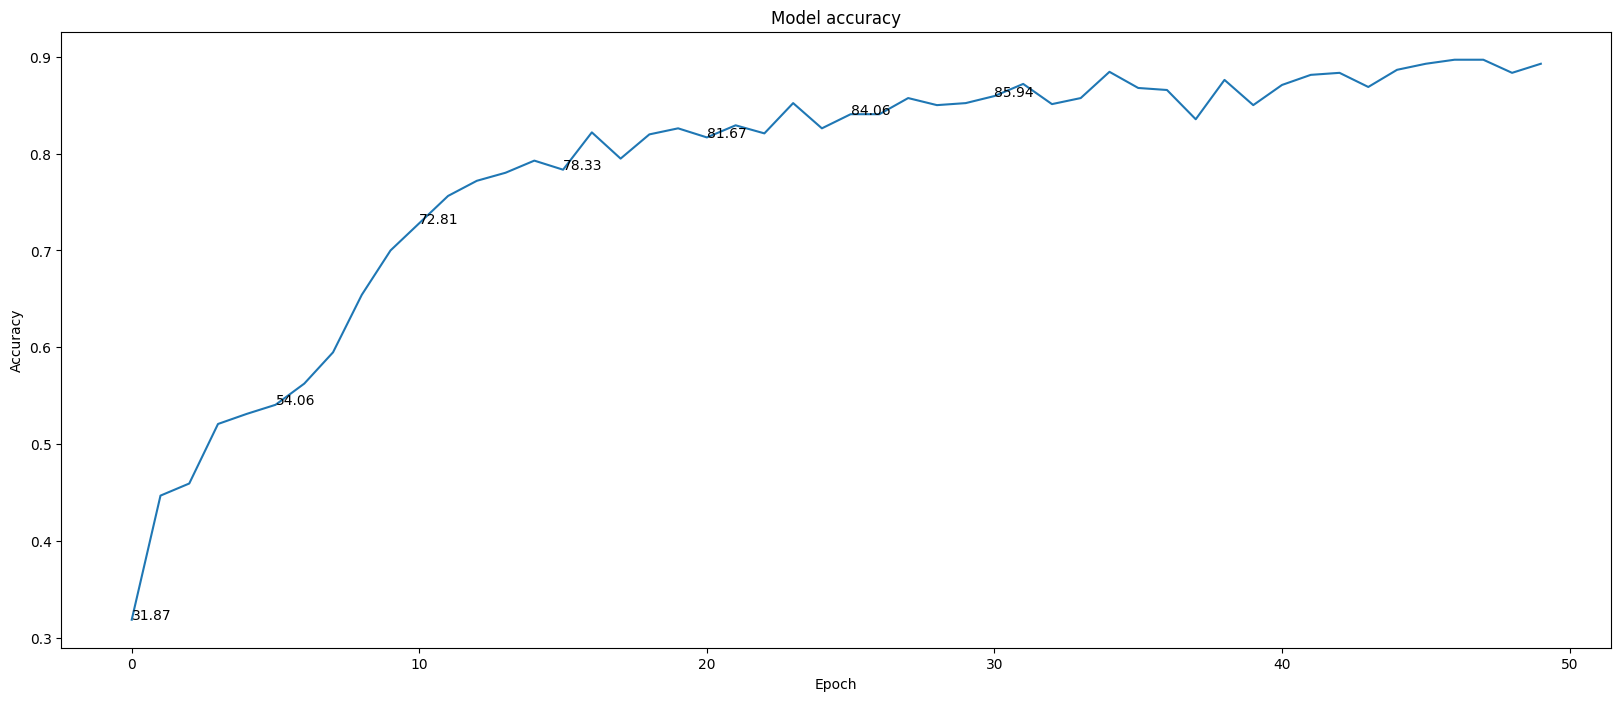

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 8))
plt.plot(history.history['accuracy'])

for i in range(34):
    if i%5 == 0:
        plt.annotate(np.round(history.history['accuracy'][i]*100,2),xy=(i,history.history['accuracy'][i]))

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

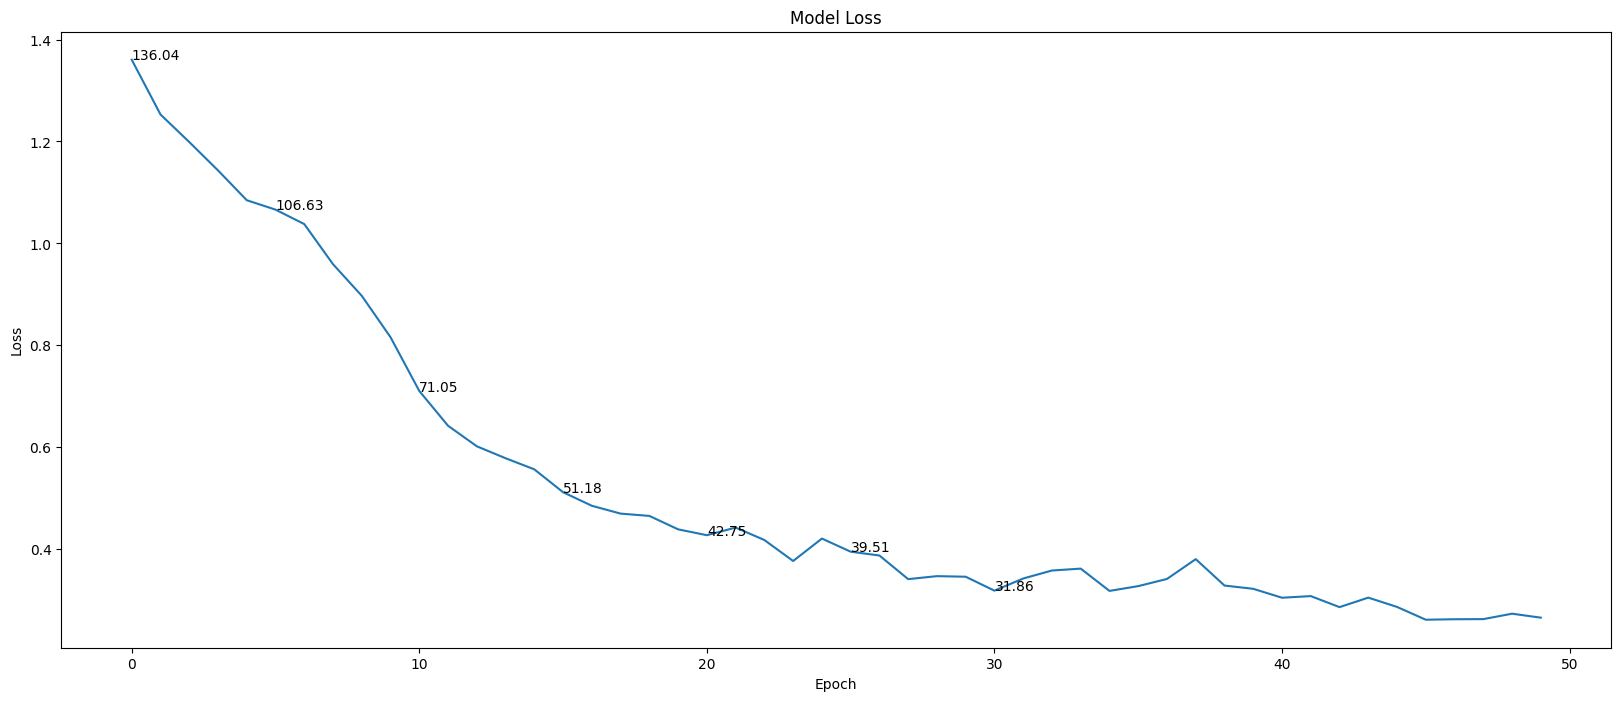

In [11]:
plt.figure(figsize=(20, 8))
plt.plot(history.history['loss'])

for i in range(34):
    if i%5 == 0:
        plt.annotate(np.round(history.history['loss'][i]*100,2),xy=(i,history.history['loss'][i]))

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()